# Extract and Visualize Individual Plants from feeds.csv

This notebook detects likely plant replacements in each `field*` column and visualizes the resulting segments.

Tune parameters in the next cell (`WINDOW`, `Z_THRESH`, `MIN_LENGTH`) and re-run cells to refine detection.

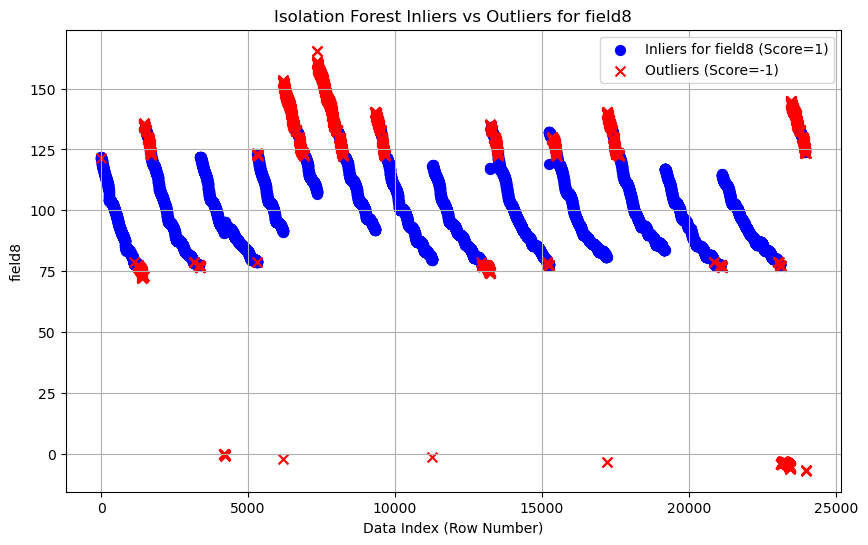

In [74]:
from sklearn.ensemble import IsolationForest

df = pd.read_csv("feeds_5.csv")
iso = IsolationForest(n_estimators=100, contamination=0.15, random_state=0)
fields = ["field1", "field2", "field3", "field4", "field5", "field6", "field7", "field8"]
for col in fields:
    iso.fit(df[[col]])
    outlier_predictions = iso.predict(df[[col]])

    df[f'is_outlier_{col}'] = outlier_predictions

field_to_plot = 'field8'
inlier_column = f'is_outlier_{field_to_plot}'

# Create a filtered DataFrame containing only inliers (where prediction == 1)
df_inliers = df[df[inlier_column] == 1].copy()# Plot the filtered data (Inliers only)
plt.figure(figsize=(10, 6))
# Plot inliers (score=1)
plt.scatter(df_inliers.index, df_inliers[field_to_plot], label=f'Inliers for {field_to_plot} (Score=1)', color='blue', s=50)

# Plot outliers (score=-1) for visual context
df_outliers = df[df[inlier_column] == -1].copy()
plt.scatter(df_outliers.index, df_outliers[field_to_plot], label='Outliers (Score=-1)', color='red', s=50, marker='x')

plt.title(f'Isolation Forest Inliers vs Outliers for {field_to_plot}')
plt.xlabel('Data Index (Row Number)')
plt.ylabel(field_to_plot)
plt.legend()
plt.grid(True)
plt.savefig('inliers_plot.png')

Finished checking column: field1
Finished checking column: field2
Finished checking column: field3
Finished checking column: field4
Finished checking column: field5
Finished checking column: field6
Finished checking column: field7
Finished checking column: field8

Bi-directional Anomalous changes in 'field1' (where change > 5):
                      created_at  entry_id  field1  field2  field3  field4  \
1986   2025-04-02T13:34:23+03:00     24660   64.89  360.41  159.72  705.84   
1987   2025-04-02T13:39:30+03:00     24661  140.14  360.58  159.70  706.39   
2160   2025-04-03T04:22:54+03:00     24834  125.38  353.82  155.00  699.00   
2161   2025-04-03T04:28:00+03:00     24835    2.38  353.85  154.96  699.02   
2162   2025-04-03T04:33:06+03:00     24836  125.31  353.72  154.93  698.91   
...                          ...       ...     ...     ...     ...     ...   
21862  2025-06-12T02:24:08+03:00     44536   52.69   -2.76  242.00  680.86   
23121  2025-06-16T13:38:31+03:00     45795   3

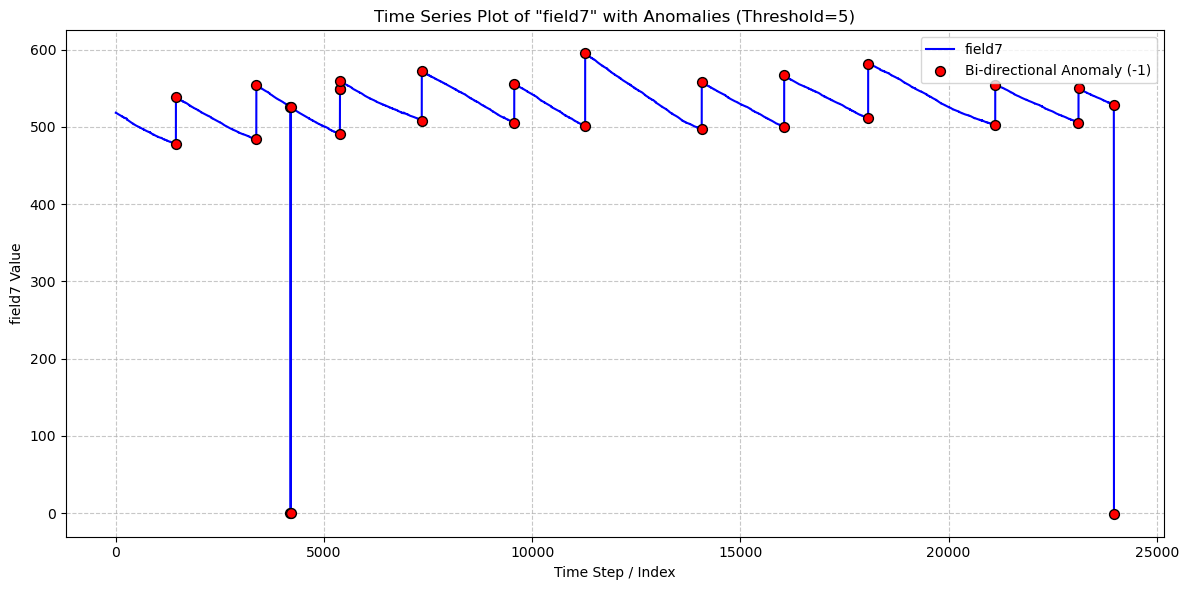

In [89]:
fields = ["field1", "field2", "field3", "field4", "field5", "field6", "field7", "field8"] 
threshold = 5
for col in fields:
    
    # 1. Calculate the absolute change from the PREVIOUS point (v_i - v_{i-1})
    diff_prev = df[col].diff().abs()
    
    # 2. Calculate the absolute change to the NEXT point (v_{i+1} - v_i)
    #    a. Calculate the difference *backward* in time (v_i - v_{i+1})
    #    b. Shift the result *backward* by one row using .shift(-1) to align (v_{i+1} - v_i)
    # The simpler approach: calculate v_i - v_{i-1} and then shift it up to get v_{i+1} - v_i (This is conceptually tricky)
    
    # EASIER WAY: Calculate the difference between the *next* point and the current point.
    # We calculate the difference of the *shifted* column and the original column.
    diff_next = (df[col].shift(-1) - df[col]).abs()
    
    # 3. Create a combined anomaly column (initialized to 1 - Normal)
    anomaly_col_name = f'is_bi_directional_anomaly_{col}'
    df[anomaly_col_name] = 1 
    
    # 4. Flag anomalies if *either* the previous OR the next change is too large
        # --- Initial Flagging into a Temporary Column ---
    temp_flag_col = f'temp_flag_{col}'
    df[temp_flag_col] = 1 # Initialize temporary flag: 1 = Normal

    # Flag potential anomalies (-1) if *either* the previous OR the next change is too large
    df.loc[(diff_prev > threshold) | (diff_next > threshold), temp_flag_col] = -1

    # --- Sequential Confirmation (Refining the Anomaly) ---
    anomaly_col_name = f'is_bi_directional_anomaly_{col}'
    # Initialize the final column with the temporary flags
    df[anomaly_col_name] = df[temp_flag_col]

    # Get the anomaly status of the next point from the temporary column
    next_anomaly_flag = df[temp_flag_col].shift(-1)

    # Get the anomaly status of the previous point from the temporary column
    prev_anomaly_flag = df[temp_flag_col].shift(1)
    # Flag rows where the change from the PREVIOUS point is too large
    # df.loc[condition, column] = value
    
    df.loc[diff_prev > threshold, anomaly_col_name] = -1
        # Flag rows where the change to the NEXT point is too large (using '|' for OR)
    df.loc[diff_next > threshold, anomaly_col_name] = -1

    
    print(f"Finished checking column: {col}")

# Display rows where any anomaly was detected in 'field1' as an example
print("\nBi-directional Anomalous changes in 'field1' (where change > 5):")
print(df[df['is_bi_directional_anomaly_field1'] == -1])

field_to_plot = 'field7'
anomaly_col = f'is_bi_directional_anomaly_{field_to_plot}'

# Identify the anomalous points for plotting
anomalies = df[df[anomaly_col] == -1]

plt.figure(figsize=(12, 6))

# Plot the main time series data
plt.plot(df.index, df[field_to_plot], label=field_to_plot, color='blue', linewidth=1.5)

# Highlight the anomalies as scatter points
plt.scatter(
    anomalies.index, 
    anomalies[field_to_plot], 
    color='red', 
    s=50, 
    zorder=5, 
    label='Bi-directional Anomaly (-1)',
    edgecolors='black'
)

plt.title(f'Time Series Plot of "{field_to_plot}" with Anomalies (Threshold={threshold})')
plt.xlabel('Time Step / Index')
plt.ylabel(field_to_plot + ' Value')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()

# Display plot (Matplotlib saves the file internally)
plt.show()

In [56]:
# Imports and helper functions
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import inspect

def detect_change_points(values, window=100, z_thresh=5.0, abs_jump=50.0, rel_jump=3.0):
    """Return list of indices (into `values`) where a change point likely occurs.

    Detection criteria (any of the following triggers a change point):
    - normalized jump (jump / rolling std) > `z_thresh`
    - absolute jump > `abs_jump`
    - relative jump (jump / rolling-median) > `rel_jump`
    """
    if len(values) < window * 2:
        return []
    series = pd.Series(values)
    rm = series.rolling(window=window, center=True, min_periods=1).median().to_numpy()
    rs = series.rolling(window=window, center=True, min_periods=1).std().to_numpy()
    jump = np.abs(np.diff(rm))
    denom = rs[:-1] + 1e-9
    z = jump / denom
    # relative jump compared to median magnitude
    rel = jump / (np.abs(rm[:-1]) + 1e-9)
    # combine criteria
    mask = (z > z_thresh) | (jump > abs_jump) | (rel > rel_jump)
    cps = np.where(mask)[0] + 1
    cps = np.unique(cps).tolist()
    return cps


def split_segments_impl(df, col, window=100, z_thresh=5.0, abs_jump=50.0, rel_jump=3.0, min_length=20, small_abs=None):
    """Return list of (start_idx, end_idx) slices (end exclusive) for column `col`.

    - `small_abs`: if not None, values with abs(value) <= small_abs are treated as empty (NaN) and ignored.
    """
    s = df[col].astype(float).reset_index(drop=True)
# --- NEW ROLLING FILTER START ---
    # 1. Calculate the 3-point rolling median (center=True uses the point itself and one on each side)
    # This helps catch both sharp drops AND sharp spikes
    rolling_median = s.rolling(window=3, center=True, min_periods=1).median()
    
    # 2. Define a maximum allowable deviation from the median (e.g., 200 units)
    # You might need to tune this threshold (e.g., 100.0 or 200.0) based on your normal data variance.
    MAX_DEVIATION = 50.0 
    
    # 3. Create a mask: Keep the value if the absolute difference is less than MAX_DEVIATION
    outlier_mask = (np.abs(s - rolling_median) > MAX_DEVIATION)
    
    # 4. Apply the filter: set outliers to NaN
    s = s.where(~outlier_mask) 
    # --- NEW ROLLING FILTER END ---
    # optionally filter out very small values (likely 'scale empty' noise)
    if small_abs is not None:
        s = s.where(np.abs(s) > small_abs)
    
    valid = s.dropna()
    if valid.empty:
        return []
    valid_idx = valid.index.to_numpy()
    vals = valid.to_numpy()
    cps = detect_change_points(vals, window=window, z_thresh=z_thresh, abs_jump=abs_jump, rel_jump=rel_jump)
    boundaries = [0] + cps + [len(vals)]
    segments = []
    for i in range(len(boundaries) - 1):
        a = boundaries[i]
        b = boundaries[i+1]
        length = b - a
        if length >= min_length:
            start_idx = valid_idx[a]
            end_idx = valid_idx[b-1] + 1
            segments.append((start_idx, end_idx))
    return segments

# Compatibility wrapper: call current implementation while remaining compatible with older code
_orig_split_segments = split_segments_impl

def split_segments(df, col, window=100, z_thresh=5.0, abs_jump=50.0, rel_jump=3.0, min_length=20, small_abs=None):
    sig = inspect.signature(_orig_split_segments)
    params = sig.parameters
    call_kwargs = {}
    if 'window' in params:
        call_kwargs['window'] = window
    if 'z_thresh' in params:
        call_kwargs['z_thresh'] = z_thresh
    if 'abs_jump' in params:
        call_kwargs['abs_jump'] = abs_jump
    if 'rel_jump' in params:
        call_kwargs['rel_jump'] = rel_jump
    if 'min_length' in params:
        call_kwargs['min_length'] = min_length
    if 'small_abs' in params:
        call_kwargs['small_abs'] = small_abs
    return _orig_split_segments(df, col, **call_kwargs)


In [103]:
# Parameters and load data
DATA_PATH = Path('feeds.csv')  # notebook is in scripts/ so feeds.csv is one level up
WINDOW = 200
Z_THRESH = 5.0
ABS_JUMP = 100.0   # absolute jump threshold to detect scale switches
REL_JUMP = 10.0    # relative jump (jump / median) threshold
MIN_LENGTH = 150
SMALL_ABS = 90  # values with abs() <= SMALL_ABS will be treated as empty/NaN (set to None to disable)
FIELDS = []  # set to None or [] to auto-detect all `field*` columns

print('Loading', DATA_PATH)
df = pd.read_csv(DATA_PATH)
print('Rows:', len(df), 'Columns:', list(df.columns))
if 'entry_id' in df.columns:
    df = df.sort_values(by='entry_id').reset_index(drop=True)
if not FIELDS:
    FIELDS = [c for c in df.columns if c.startswith('field')]
print('Processing fields:', FIELDS)


Loading feeds.csv
Rows: 46647 Columns: ['created_at', 'entry_id', 'field1', 'field2', 'field3', 'field4', 'field5', 'field6', 'field7', 'field8', 'latitude', 'longitude', 'elevation', 'status']
Processing fields: ['field1', 'field2', 'field3', 'field4', 'field5', 'field6', 'field7', 'field8']


In [104]:
# Detect segments and build a summary dataframe
import inspect
summary = []
all_segments = {}
for field in FIELDS:
    print(f'\nField: {field}')
    if field not in df.columns:
        print('  missing column, skipping')
        continue
    # Call split_segments in a signature-safe manner (only pass supported kwargs)
    sig = inspect.signature(split_segments)
    params = sig.parameters
    call_kwargs = {}
    if 'window' in params:
        call_kwargs['window'] = WINDOW
    if 'z_thresh' in params:
        call_kwargs['z_thresh'] = Z_THRESH
    if 'abs_jump' in params:
        call_kwargs['abs_jump'] = ABS_JUMP
    if 'rel_jump' in params:
        call_kwargs['rel_jump'] = REL_JUMP
    if 'min_length' in params:
        call_kwargs['min_length'] = MIN_LENGTH
    if 'small_abs' in params:
        call_kwargs['small_abs'] = SMALL_ABS

    segs = split_segments(df, field, **call_kwargs)
    print(f'  found {len(segs)} segments')
    all_segments[field] = segs
    for i, (start, end) in enumerate(segs, start=1):
        seg = df.iloc[start:end].copy()
        start_id = seg.iloc[0]['entry_id'] if 'entry_id' in seg.columns else start
        end_id = seg.iloc[-1]['entry_id'] if 'entry_id' in seg.columns else end-1
        summary.append({
            'field': field, 'segment': i, 'start_idx': int(start), 'end_idx': int(end-1),
            'start_entry_id': int(start_id) if pd.notna(start_id) else None,
            'end_entry_id': int(end_id) if pd.notna(end_id) else None,
            'n_samples': int(end-start),
            'mean': float(seg[field].astype(float).mean()),
            'std': float(seg[field].astype(float).std()),
        })

summary_df = pd.DataFrame(summary)
display(summary_df.head(200))
print('Total segments:', len(summary_df))



Field: field1
  found 5 segments

Field: field2
  found 11 segments

Field: field3
  found 2 segments

Field: field4
  found 4 segments

Field: field5
  found 5 segments

Field: field6
  found 10 segments

Field: field7
  found 5 segments

Field: field8
  found 6 segments


,field,segment,start_idx,end_idx,start_entry_id,end_entry_id,n_samples,mean,std
0,field1,1,39,7535,40,7536,7497,790.162818,85.581598
1,field1,2,7537,12979,7538,12980,5443,823.357825,97.806826
2,field1,3,12982,17375,12983,17376,4394,1016.914538,88.080128
3,field1,4,17379,22633,17380,22634,5255,550.106339,156.039167
4,field1,5,22634,42640,22635,42641,20007,90.630308,27.489398
5,field2,1,39,6197,40,6198,6159,1289.069523,179.195384
6,field2,2,6200,6720,6201,6721,521,1171.012514,314.320511
7,field2,3,6722,7393,6723,7394,672,1288.813214,209.868660
8,field2,4,7395,9210,7396,9211,1816,1378.804389,127.638963
9,field2,5,9690,9878,9691,9879,189,725.944709,13.075361


Total segments: 48


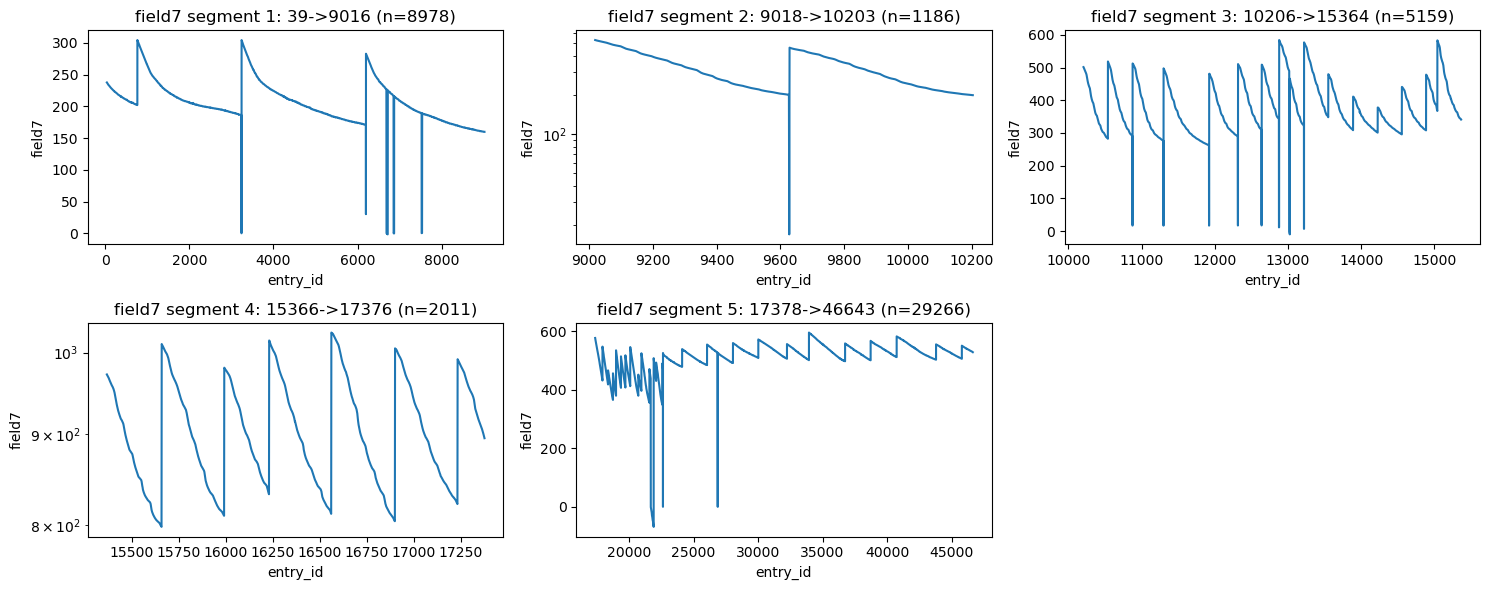

In [105]:
# Plot up to N example segments for the first chosen field
FIELD_TO_PLOT = FIELDS[6] if FIELDS else None
N_EXAMPLES = 12
if FIELD_TO_PLOT and FIELD_TO_PLOT in all_segments:
    segs = all_segments[FIELD_TO_PLOT]
    examples = segs[:N_EXAMPLES]
    n = len(examples)
    if n == 0:
        print('No segments to plot for', FIELD_TO_PLgOT)
    else:
        cols = min(3, n)
        rows = (n + cols - 1) // cols
        plt.figure(figsize=(5*cols, 3*rows))
        for i, (start, end) in enumerate(examples, start=1):
            seg = df.iloc[start:end].reset_index(drop=True)
            ax = plt.subplot(rows, cols, i)
            x = seg['entry_id'] if 'entry_id' in seg.columns else np.arange(len(seg))
            y = seg[FIELD_TO_PLOT].astype(float)
            ax.plot(x, y, '-', markersize=3)
            ax.set_title(f'{FIELD_TO_PLOT} segment {i}: {start}->{end-1} (n={len(seg)})')
            ax.set_xlabel('entry_id')
            ax.set_ylabel(FIELD_TO_PLOT)
            try:
                if (y > 0).all():
                    ax.set_yscale('log')
            except Exception:
                pass
            plt.tight_layout()
        plt.show()
else:
    print('No field selected or missing segments to plot')

Eemaldan read, kus field7 < 70...

--- Jagamine Entry ID 22673 järgi ---
Segment 1 (Enne Entry ID 22673): Entry ID Algus=39, Lõpp=8982, Pikkus=8882
Segment 2 (Enne Entry ID 22673): Entry ID Algus=8983, Lõpp=15330, Pikkus=6324
Segment 3 (Enne Entry ID 22673): Entry ID Algus=15331, Lõpp=17342, Pikkus=2012
Segment 4 (Enne Entry ID 22673): Entry ID Algus=17343, Lõpp=22668, Pikkus=5094


C:\Users\kevinnoormets\AppData\Local\Temp\ipykernel_35404\4087671244.py:70: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  smoothed_values = subset['smoothed'].fillna(method='bfill').fillna(method='ffill').values


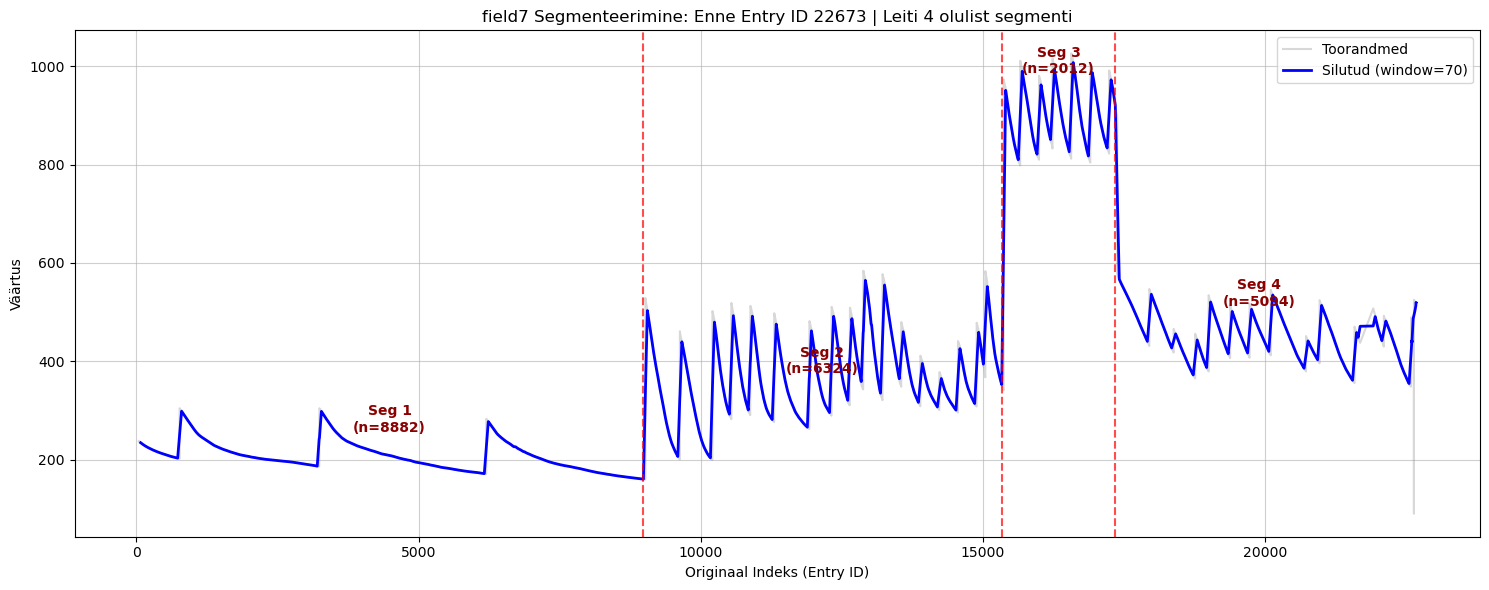

Enne Entry ID 22673: Leiti kokku 4 segmenti, mis on pikemad kui 300 punkti.
Segment 1 (Pärast Entry ID 22673): Entry ID Algus=22673, Lõpp=24082, Pikkus=1410
Segment 2 (Pärast Entry ID 22673): Entry ID Algus=24083, Lõpp=26013, Pikkus=1931
Segment 3 (Pärast Entry ID 22673): Entry ID Algus=26014, Lõpp=28021, Pikkus=1992
Segment 4 (Pärast Entry ID 22673): Entry ID Algus=28022, Lõpp=29987, Pikkus=1966
Segment 5 (Pärast Entry ID 22673): Entry ID Algus=29988, Lõpp=32208, Pikkus=2221
Segment 6 (Pärast Entry ID 22673): Entry ID Algus=32209, Lõpp=33911, Pikkus=1703
Segment 7 (Pärast Entry ID 22673): Entry ID Algus=33912, Lõpp=36711, Pikkus=2800
Segment 8 (Pärast Entry ID 22673): Entry ID Algus=36712, Lõpp=38691, Pikkus=1980
Segment 9 (Pärast Entry ID 22673): Entry ID Algus=38692, Lõpp=40708, Pikkus=2017
Segment 10 (Pärast Entry ID 22673): Entry ID Algus=40709, Lõpp=43760, Pikkus=3052
Segment 11 (Pärast Entry ID 22673): Entry ID Algus=43761, Lõpp=45760, Pikkus=2000
Segment 12 (Pärast Entry ID 226

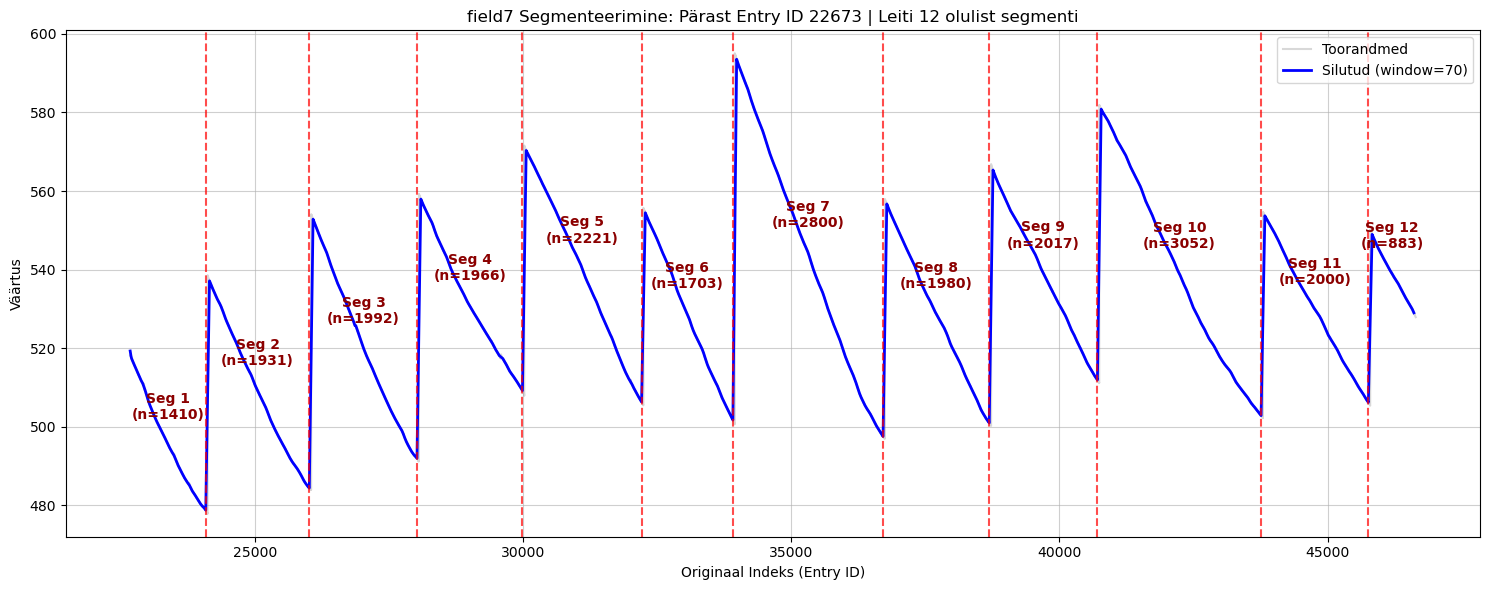

Pärast Entry ID 22673: Leiti kokku 12 segmenti, mis on pikemad kui 300 punkti.

Joonistamine lõpetatud.
[(np.int64(22673), np.int64(24082)), (np.int64(24083), np.int64(26013)), (np.int64(26014), np.int64(28021)), (np.int64(28022), np.int64(29987)), (np.int64(29988), np.int64(32208)), (np.int64(32209), np.int64(33911)), (np.int64(33912), np.int64(36711)), (np.int64(36712), np.int64(38691)), (np.int64(38692), np.int64(40708)), (np.int64(40709), np.int64(43760)), (np.int64(43761), np.int64(45760)), (np.int64(45761), np.int64(46643))]


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- KONFIGURATSIOON ---
FIELD = 'field7'
plots = []
VAL_THRESHOLD = 70      # Filtreeri välja punktid, mille väärtus on alla selle
USE_VAL_FILTER = True   # Muuda True-ks, kui tahad tegelikult eemaldada kõik väärtused < VAL_THRESHOLD'i

SMOOTH_WINDOW = 70     # Suurem number = sujuvam joon
Z_THRESH = 8.0          # Kõrgem number = süsteem on vähem tundlik väikestele muutustele
MIN_SEGMENT_LENGTH = 300 # Segmendid, mis on lühemad kui see arv punkte, visatakse minema
SPLIT_INDEX = 22673     # Indeks (entry_id), mille järgi andmed kaheks jagatakse
# ----------------------

# 1. Laeme andmed ja valmistame ette
df = pd.read_csv('feeds.csv')

# Teeme koopia ja salvestame originaalse indeksi (eeldame, et see on entry_id)
data = df.copy()
data['original_index'] = data.index
data[FIELD] = pd.to_numeric(data[FIELD], errors='coerce')

# Filtreeri välja väikesed väärtused
if USE_VAL_FILTER:
    print(f"Eemaldan read, kus {FIELD} < {VAL_THRESHOLD}...")
    data = data[data[FIELD] >= VAL_THRESHOLD]

# Eemaldame tühjad read ja lähtestame indeksi (ajutiseks sisemiseks käsitluseks)
data = data.dropna(subset=[FIELD]).reset_index(drop=True)

# 2. Silumine (Rolling Mean) - kogu andmestiku peale
# Seda tehakse kogu andmestiku peale, et vältida artefakte poolituskohtades.
data['smoothed'] = data[FIELD].rolling(window=SMOOTH_WINDOW, center=True).mean()


# Funktsioon muutuste leidmiseks (algne segmenteerimisloogika)
def get_segments(values, z_thresh):
    """Leiab segmendipõhised muutuskohad vastavalt Z-lävele ja minimaalse segmendi pikkusele."""
    diffs = np.abs(np.diff(values, prepend=values[0]))
    
    # Kasutame robustsemat statistikat (kvartiilide vahemik)
    q75, q25 = np.percentile(diffs, [75 ,25])
    iqr = q75 - q25
    if iqr == 0: iqr = 1 # Väldi nulliga jagamist
    
    norm_diffs = diffs / iqr
    
    # Leiame potentsiaalsed katkestuskohad
    change_points = np.where(norm_diffs > z_thresh)[0]
    
    # Filtreerime katkestuskohad, mis on üksteisele liiga lähedal
    valid_points = [0]
    last_point = 0
    for cp in change_points:
        if cp - last_point > MIN_SEGMENT_LENGTH:
            valid_points.append(cp)
            last_point = cp
            
    valid_points.append(len(values))
    return valid_points

# 3. Andmestiku jagamine ja joonistamise funktsioon

def plot_segmentation(subset, title_suffix):
    """Joonistab segmenteeritud andmete alamhulga."""
    
    # Eraldame alamhulga silutud andmed (täidame NaN-id, mis tekkisid rolling mean'iga)
    smoothed_values = subset['smoothed'].fillna(method='bfill').fillna(method='ffill').values
    
    # Leiame segmendid konkreetses alamhulgas
    points = get_segments(smoothed_values, Z_THRESH)

    plt.figure(figsize=(15, 6))
    
    # Kasutame x-teljel originaalindeksit
    x_indices = subset['original_index']
    
    plt.plot(x_indices, subset[FIELD], label='Toorandmed', alpha=0.3, color='gray')
    plt.plot(x_indices, subset['smoothed'], label=f'Silutud (window={SMOOTH_WINDOW})', color='blue', linewidth=2)

    final_segments_count = 0
    
    # Arvutame dünaamilise nihke praeguse graafiku Y-vahemiku põhjal
    y_range = subset['smoothed'].max() - subset['smoothed'].min()
    offset = 0.05 * y_range 

    # Käime läbi segmendid (points sisaldab lokaalseid indekseid 0..len(subset))
    for i in range(len(points) - 1):
        start_local, end_local = points[i], points[i+1]
        segment_len = end_local - start_local
        
        # Jätame välja mürasegmendid
        if segment_len >= MIN_SEGMENT_LENGTH:
            final_segments_count += 1

            start_entry_id = x_indices.iloc[start_local]

            end_entry_id = x_indices.iloc[end_local - 1]
            
            # Keskpunkt lokaalses indeksis
            mid_local = int(start_local + (end_local - start_local) / 2)
            
            # X-positsioon (originaal indeks) ja Y-positsioon (silutud väärtus)
            mid_x_original = x_indices.iloc[mid_local]
            y_pos = subset['smoothed'].iloc[mid_local]

            print(f"Segment {final_segments_count} ({title_suffix}): Entry ID Algus={start_entry_id}, Lõpp={end_entry_id}, Pikkus={segment_len}")
            plots.append((start_entry_id, end_entry_id))
            # Vertikaalne joon segmendi algusesse (v.a esimene segment)
            if start_local > 0:
                plt.axvline(x=x_indices.iloc[start_local], color='red', linestyle='--', alpha=0.7)
            
            # Märgime segmendi numbri. y_pos + offset tõstab teksti ülespoole, va='bottom'
            # tähendab, et teksti alumine äär algab sealt joonest.
            plt.text(mid_x_original, y_pos + offset, f'Seg {final_segments_count}\n(n={segment_len})', 
                     ha='center', va='bottom', fontweight='bold', color='darkred') 

    plt.title(f'{FIELD} Segmenteerimine: {title_suffix} | Leiti {final_segments_count} olulist segmenti')
    plt.xlabel('Originaal Indeks (Entry ID)')
    plt.ylabel('Väärtus')
    plt.legend()
    plt.grid(True, alpha=0.6)
    plt.tight_layout()
    plt.show()
    
    print(f"{title_suffix}: Leiti kokku {final_segments_count} segmenti, mis on pikemad kui {MIN_SEGMENT_LENGTH} punkti.")
    return (start_entry_id, end_entry_id)


# --- JAGAMINE JA JOONISTAMINE ---

# Leidke jagamiskoht (kasutades originaalindeksit)
split_point_index = data[data['original_index'] >= SPLIT_INDEX].index.min()
if pd.isna(split_point_index):
    split_point_index = len(data) # Kui indeksit ei leitud, joonista kõik
    
# Jagame andmed
data_part1 = data.iloc[:split_point_index].copy()
data_part2 = data.iloc[split_point_index:].copy()

print(f"\n--- Jagamine Entry ID {SPLIT_INDEX} järgi ---")

# Joonista esimene osa
plot_segmentation(data_part1, f"Enne Entry ID {SPLIT_INDEX}")

# Joonista teine osa
if not data_part2.empty:
    plot_segmentation(data_part2, f"Pärast Entry ID {SPLIT_INDEX}")
else:
    print("Märkus: Teine andmekogum (pärast jagamispunkti) on tühi.")

print("\nJoonistamine lõpetatud.")
print(plots[4:])

## Next steps and tuning
- If the notebook finds many small segments, increase `MIN_LENGTH` or `Z_THRESH`.
- If it misses replacements, lower `Z_THRESH` or reduce `WINDOW`.
- To export per-segment CSVs, iterate `summary_df` and call `df.iloc[start:end].to_csv(...)`.
- For more robust change-point detection consider `ruptures` or Bayesian approaches; this notebook prioritizes a fast, interactive heuristic.